## Time-varying DDM

Autocorrelated fluctuations in $v$, $z$, and $a$

In [1]:
import numpy as np
import os
from numba import njit
import bayesflow as bf
import tensorflow as tf
from functions import _CustomTwoLevelPrior, _Custom_Simulator, _CustomTwoLevelGenerativeModel
from scipy.stats import beta, gamma, uniform, spearmanr, pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32

import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)
from tensorflow.python.platform import build_info as tf_build_info
print("cudnn_version",tf_build_info.build_info['cudnn_version'])
print("cuda_version",tf_build_info.build_info['cuda_version'])

2026-06-16 23:39:16.411596: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-16 23:39:18.440998: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-16 23:39:18.441067: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-16 23:39:18.810453: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-16 23:39:19.511015: I tensorflow/core/platform/cpu_feature_guar

2026-06-16 23:39:22.731082: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


cudnn_version 8
cuda_version 12.2


In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Create folder if it does not exist
os.makedirs("Figures", exist_ok=True)
os.makedirs("Data", exist_ok=True)

## Set priors

In [4]:
RNG = np.random.default_rng(0)

min_n_trials = 350
max_n_trials = 3250

batch_size = 32

"""
Set parameters for prior distributions 
"""

# uniform for drift rate, starting point, boundary, and non-decision time
v_lower, v_upper = 0.0, 5.0
z_lower, z_upper = -2.0, 2.0
a_lower, a_upper = 0.1, 5.0
ter_lower, ter_upper = 0.01, 1.0

# uniform for phi and sigma of AR(1) process
phi_v_bias_lower, phi_v_bias_upper = 0.0, 1.0
phi_z_bias_lower, phi_z_bias_upper = 0.0, 1.0
phi_a_bias_lower, phi_a_bias_upper = 0.0, 1.0

sigma_v_bias_lower, sigma_v_bias_upper = 0.0, 4.0
sigma_z_bias_lower, sigma_z_bias_upper = 0.0, 2.0
sigma_a_bias_lower, sigma_a_bias_upper = 0.0, 2.0

## Prior functions

In [5]:
def sample_shared_parameters():
    """
    Shared parameters are parameters that stay constant over trials within a subject
    and are not related to the AR(1) processes for starting point bias and drift bias
    """
    
    v = np.random.uniform(v_lower, v_upper) # drift rate
    z = np.random.uniform(z_lower, z_upper) # starting point (relative to boundary)
    a = np.random.uniform(a_lower, a_upper) # boundary
    ter = np.random.uniform(ter_lower, ter_upper) # non-decision time
    
    shared_parameters = np.concatenate([np.r_[v, z, a, ter]])
    
    return shared_parameters

In [6]:
def sample_hyper_parameters():
    """
    Hyper parameters govern the AR(1) process for starting point bias and drift bias.
    Following hyper parameters are sampled separately for the AR(1) of starting point bias and drift bias:    
    autoregressive coefficient (phi), and sigma.
    
    Note that the fluctuating value for starting point is a actually a bias that we add to 
    the .5 to obtain the starting point (see def _sample_one_diffusion_trial)
    This is easier to implement than a time series that should fluctuate around .5, 
    """
    
    phi_v_bias = np.random.uniform(phi_v_bias_lower, phi_v_bias_upper)
    phi_z_bias = np.random.uniform(phi_z_bias_lower, phi_z_bias_upper)
    phi_a_bias = np.random.uniform(phi_a_bias_lower, phi_a_bias_upper)

    sigma_v_bias = np.random.uniform(sigma_v_bias_lower, sigma_v_bias_upper)
    sigma_z_bias = np.random.uniform(sigma_z_bias_lower, sigma_z_bias_upper)
    sigma_a_bias = np.random.uniform(sigma_a_bias_lower, sigma_a_bias_upper)

    hyper_parameters = np.concatenate([np.r_[phi_v_bias, sigma_v_bias, phi_z_bias, sigma_z_bias, phi_a_bias, sigma_a_bias]])
    
    return hyper_parameters
    

In [7]:
def sample_local_parameters(shared_parameters, hyper_parameters, condition_matrix, num_trials): # hyper_params, local_batchable_context, local_non_batchable_context provided by local_context_generator in TwoLevelPrior
    """
    Local parameters are the trial-to-trial fluctuations in drift bias and starting point bias
    Takes in hyperparameters for AR(1) process
    """
    
    a = shared_parameters[2]
    
    phi_v_bias = hyper_parameters[0]
    sigma_v_bias = hyper_parameters[1]
    
    phi_z_bias = hyper_parameters[2]
    sigma_z_bias = hyper_parameters[3]
    
    phi_a_bias = hyper_parameters[4]
    sigma_a_bias = hyper_parameters[5]
    
    # Initialize first value for drift bias (first column), starting point bias (second column), boundary bias (third column)
    local_parameters = np.zeros((num_trials,3))
    
    local_parameters[0,0] = 0.0
    local_parameters[0,1] = 0.0
    local_parameters[0,2] = 0.0
    
    # Run AR(1) from initial value: x_t = phi * x_t-1 + N(0,sigma)
    for t in range(1, num_trials):
        
        # Drift bias
        local_parameters[t,0] = phi_v_bias * local_parameters[t-1, 0] + np.random.normal(0.0, sigma_v_bias) 

        # Starting point bias
        local_parameters[t,1] = phi_z_bias * local_parameters[t-1, 1] + np.random.normal(0.0, sigma_z_bias) 
        
        # Boundary bias
        local_parameters[t,2] = np.clip(
                                phi_a_bias * local_parameters[t-1, 2] + np.random.normal(0.0, sigma_a_bias),
                                a_min=0.1-a, a_max=1e5 # restrict a_t such that a + a_t is always > 0.1
                                )

    return local_parameters
    

## Sample diffusion trial

In [8]:
@cuda.jit
def _sample_one_diffusion_trial(rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias, num_threads):
    """
    Generates a single response time from a Diffusion Decision process.
    """
    
    thread_id = cuda.grid(1)
    
    if (thread_id < num_threads):
        
        # Input parameters
        v = in_v[thread_id]
        z = in_z[thread_id]
        a = in_a[thread_id]
        ter = in_ter[thread_id]
        v_bias = in_v_bias[thread_id]
        z_bias = in_z_bias[thread_id]
        a_bias = in_a_bias[thread_id]
        
        # Simulation parameters
        dt=0.005             # time resolution of process, 5 milliseconds
        max_iter=int(20/dt)  # max iterations of the process, 20 seconds
        s=1.0                # scaling factor of the Wiener noise
        c = (dt * s)**0.5    # np.sqrt does not work with cuda.jit     

        # Initialize
        transformed_z = 1/(1+math.exp(-(z+z_bias))) # constrain z + z_bias between 0 and 1 with sigmoid transformation
        evidence = (a+a_bias) * (transformed_z)     # initialize first value (starting point plus bias relative to boundary)
        slope = v+v_bias                            # v and v_bias are both already multiplied with stimulus (effectively making 'slope' a fluctuating drift rate)
        slope_dt = slope*dt
        n_iter = 0
        
        # Diffusion process
        while evidence > 0 and evidence < (a+a_bias) and n_iter < max_iter:
            n_iter += 1
            evidence += slope_dt + c * xoroshiro128p_normal_float32(rng_states, thread_id)
    
        # Determine response
        rt = n_iter * dt + ter
        
        if evidence >= (a+a_bias):
            resp =  1
        elif evidence <= 0:
            resp = 0
        else:
            resp = -99
            
        out_rt[thread_id] = rt
        out_resp[thread_id] = resp

## Cuda helper functions

In [9]:
@njit(fastmath=True)
def cuda_convert_parameters(parameters, condition_matrix):
    """
    Convert the batched parameters into a vector for each parameter separately
    """
    
    local_parameters = parameters[0]
    shared_parameters = parameters[1]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    in_v = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_ter = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_v_bias = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_z_bias = np.zeros(batch_size * num_trials, dtype=np.float32)
    in_a_bias = np.zeros(batch_size * num_trials, dtype=np.float32)

    for dataset in range(batch_size): # loop over datasets
    
        local_parameters_subset = local_parameters[dataset]
        shared_parameters_subset = shared_parameters[dataset]
        condition_matrix_subset = condition_matrix[dataset]
        
        for trial in range(num_trials): # loop over trials
                
            in_index = dataset * num_trials + trial

            in_v[in_index] = shared_parameters_subset[0] * condition_matrix_subset[trial] # multiply drift rate with stimulus
            in_z[in_index] = shared_parameters_subset[1]
            in_a[in_index] = shared_parameters_subset[2]
            in_ter[in_index] = shared_parameters_subset[3]
            in_v_bias[in_index] = local_parameters_subset[trial,0] * condition_matrix_subset[trial] # by multiplying with stimulus here we effectively create a fluctuating drift rate, instead of drift bias
            in_z_bias[in_index] = local_parameters_subset[trial,1]
            in_a_bias[in_index] = local_parameters_subset[trial,2]

    return in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias


@njit(fastmath=True)
def cuda_convert_sim_data(parameters, condition_matrix, out_rt, out_resp):
    
    local_parameters = parameters[0]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    out = np.zeros((batch_size, num_trials, 2), dtype=np.float32) # rt, resp

    for dataset in range(batch_size): # loop over datasets
        for trial in range(num_trials): # loop over trials

            # simulated data as a 3D tensor of shape (num_datasets, num_trials, num_variables)
            out_index = dataset * num_trials + trial
            out[dataset, trial, :] = np.array([out_rt[out_index], out_resp[out_index]], dtype=np.float32)

    return out

## Sample multiple diffusion trials

In [10]:
def sample_multiple_diffusion_trials(parameters, condition_matrix): # condition matrix is given by _CustomTwoLevelGenerativeModel as batchable_context (see functions.py line 484)
    """Generates a single simulation from DDM with starting point bias and
    drift bias following an AR(1) model.

    parameters : a tuple consisting of (local_parameters, shared_parameters)
                 as returned by the generator function to the simulator (likelihood) function
                 see source code https://bayesflow.org/_modules/bayesflow/amortizers.html#TwoLevelAmortizedPosterior
    """

    local_parameters = parameters[0]
    
    batch_size = local_parameters.shape[0]
    num_trials = local_parameters.shape[1]

    threads_per_block = 32
    total_threads = int(batch_size * num_trials)
    blocks = math.ceil(total_threads / threads_per_block)
    rng_states = create_xoroshiro128p_states(total_threads, seed=0)
    
    # parameters and conditions_matrix should be batched! 
    in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias = cuda_convert_parameters(parameters, condition_matrix)    
    
    # one iteration happens fully in parallel (so each trial for all datasets in parallel)
    out_rt = np.zeros(batch_size * num_trials, dtype=np.float32)
    out_resp = np.zeros(batch_size * num_trials, dtype=np.float32)

    _sample_one_diffusion_trial[blocks, threads_per_block](rng_states, out_rt, out_resp, in_v, in_z, in_a, in_ter, in_v_bias, in_z_bias, in_a_bias, total_threads)

    out = cuda_convert_sim_data(parameters, condition_matrix, out_rt, out_resp)
    
    return out

## Helper functions

In [11]:
def return_mean_std_shared_parameters():
    """
    Return the mean and standard deviation of shared parameters
    """
    
    v_mean, v_std = uniform.stats(v_lower, v_upper, moments='mv')
    z_mean, z_std = uniform.stats(z_lower, z_upper, moments='mv')
    a_mean, a_std =  uniform.stats(a_lower, a_upper, moments='mv')
    ter_mean, ter_std =  uniform.stats(ter_lower, ter_upper, moments='mv')
    
    mean_shared = np.array([v_mean, z_mean, a_mean, ter_mean])
    std_shared = np.array([v_std, z_std, a_std, ter_std])
    
    return mean_shared, std_shared



def return_mean_std_hyper_parameters():
    """
    Return the mean and standard deviation of hyperparameters 
    """
    
    phi_v_bias_mean, phi_v_bias_var = uniform.stats(phi_v_bias_lower, phi_v_bias_upper, moments='mv')
    phi_z_bias_mean, phi_z_bias_var = uniform.stats(phi_z_bias_lower, phi_z_bias_upper, moments='mv')
    phi_a_bias_mean, phi_a_bias_var = uniform.stats(phi_a_bias_lower, phi_a_bias_upper, moments='mv')
    
    sigma_v_bias_mean, sigma_v_bias_var = uniform.stats(sigma_v_bias_lower, sigma_v_bias_upper, moments='mv')
    sigma_z_bias_mean, sigma_z_bias_var = uniform.stats(sigma_z_bias_lower, sigma_z_bias_upper, moments='mv')    
    sigma_a_bias_mean, sigma_a_bias_var = uniform.stats(sigma_a_bias_lower, sigma_a_bias_upper, moments='mv')  
    
    # must have same order as output from sample_hyper_parameters()
    mean_hyper = np.array([phi_v_bias_mean, sigma_v_bias_mean, phi_z_bias_mean, sigma_z_bias_mean, phi_a_bias_mean, sigma_a_bias_mean])
    std_hyper = np.sqrt(np.array([phi_v_bias_var, sigma_v_bias_var, phi_z_bias_var, sigma_z_bias_var, phi_a_bias_var, sigma_a_bias_var]))
    
    return mean_hyper, std_hyper

In [12]:
def sample_n_trials(min_n_trials=min_n_trials, max_n_trials=max_n_trials):
    """
    Samples the number of trials used for all simulations in one batch.
    """
    
    num_trials = np.random.randint(min_n_trials, max_n_trials+1)
    
    return num_trials



def generate_condition_matrix(num_trials):
    """
    Draws a random design matrix (stimulus: either -1 or +1 on each trial) for each simulation in a batch.
    """

    condition_matrix = np.random.uniform(-1, 1, size=num_trials)
    
    return condition_matrix

## Setting up generator

In [13]:
""" 

6 hyper parameters (phi_v_bias, phi_z_bias, phi_a_bias, sigma_v_bias, sigma_z_bias, sigma_a_bias)
3 local parameters (v_bias, z_bias, a_bias)
4 shared parameters (v, a, z, ter)



"""


experimental_context = bf.simulation.ContextGenerator(non_batchable_context_fun=sample_n_trials,
                                                      batchable_context_fun=generate_condition_matrix,
                                                      use_non_batchable_for_batchable=True)

prior = _CustomTwoLevelPrior( # custom function that enables local parameters to be constrained by shared parameters (if relu1 for z bias and z is used)
    hyper_prior_fun=sample_hyper_parameters,
    local_prior_fun=sample_local_parameters,
    shared_prior_fun=sample_shared_parameters,
    local_context_generator=experimental_context # provides num_trials and condition_matrix to local_prior_fun (see source code https://bayesflow.org/_modules/bayesflow/simulation.html#TwoLevelPrior)
)

# likelihood only takes in local and shared priors, not the hyper priors (see source code https://bayesflow.org/_modules/bayesflow/simulation.html#TwoLevelGenerativeModel)
# generator outputs both parameters (local and shared priors, not hyper) and batchable context to likelihood 
# _Custom_Simulator makes sure that the batchable context (condition matrix) from prior is used, despite empty context_generator here in likelihood function
likelihood = _Custom_Simulator(
     batch_simulator_fun=sample_multiple_diffusion_trials
)

# _CustomTwoLevelGenerativeModel: outputs both parameters and batchable context (design_matrix) from prior to likelihood as input, see line 484 in functions.py
generator = _CustomTwoLevelGenerativeModel(
     prior=prior,
     simulator=likelihood,
     name="ar1_ddm"
 )


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/dispatcher.py:697: NumbaPerformanceWarning: Grid size 66 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/cuda/core/experimental/_linker.py:189: RuntimeWarning: nvJitLink is not installed or too old (<12.3). Therefore it is not usable and the culink APIs will be used instead.
  _lazy_init()
/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


INFO:root:Performing 2 pilot runs with the ar1_ddm model...


INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1048, 3)


INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 1048, 2)


...

INFO:root:Shape of shared_prior_draws batch after 2 pilot simulations: (batch_size = 2, 4)


INFO:root:Could not determine shape of simulation batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes care of that!


INFO:root:No optional simulation non-batchable context provided.


INFO:root:Could not determine shape of prior batchable context. Type appears to be non-array: <class 'list'>,                                    so make sure your input configurator takes care of that!


INFO:root:Could not determine shape of prior non-batchable context. Type appears to be non-array: <class 'int'>,                                    so make sure your input configurator takes care of that!


## Checking prior values

In [14]:
# Sample 10000 parameter values
plot_prior = prior(batch_size=10000)

### Shared parameters

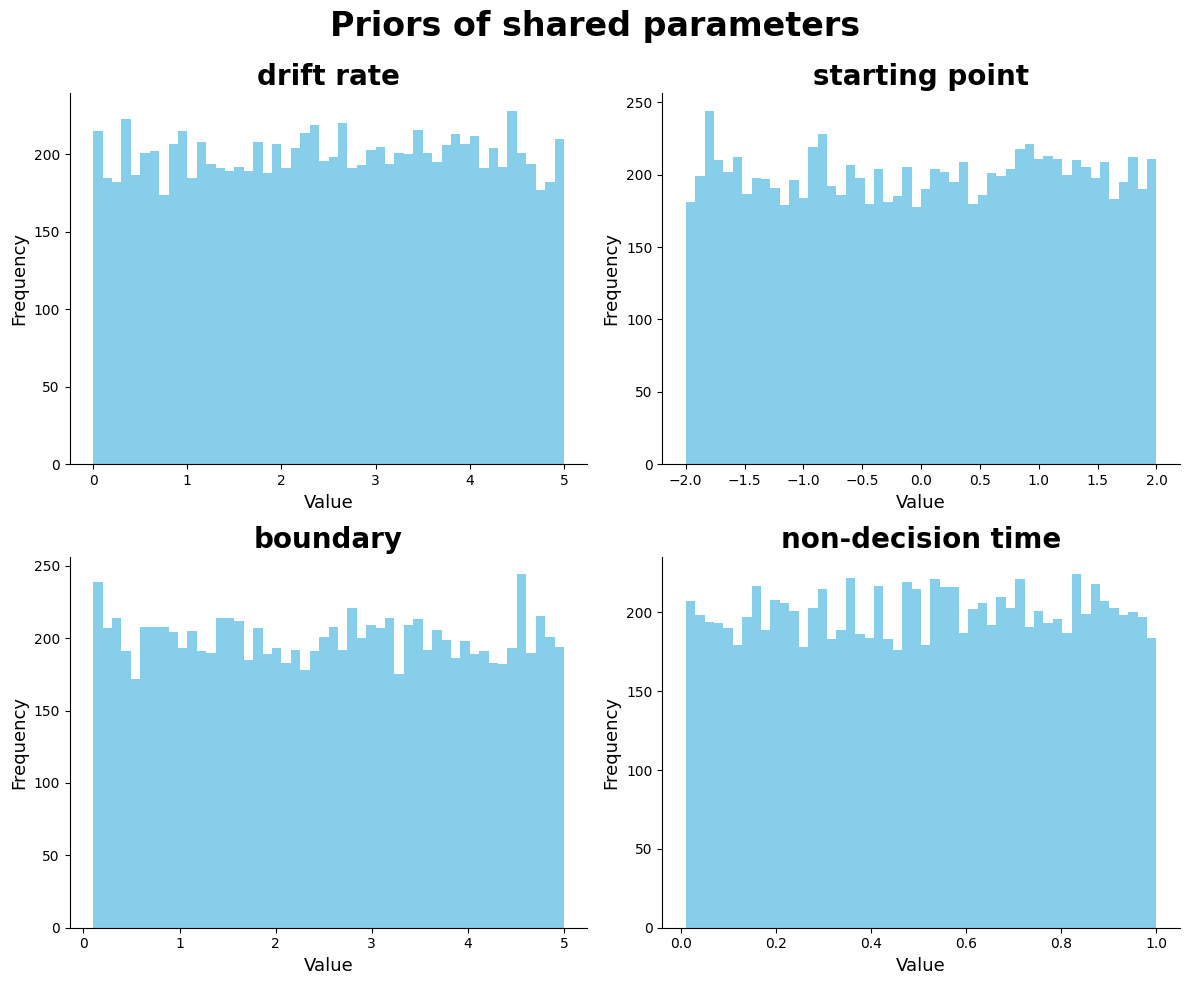

In [15]:
shared_param_labels = ["drift rate","starting point","boundary","non-decision time"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, ax in enumerate(axes.flatten()):
    ax.hist(plot_prior['shared_parameters'][:, i], bins=50, color='skyblue')
    ax.set_xlabel("Value", fontsize=13)
    ax.set_ylabel("Frequency", fontsize=13)
    ax.set_title(shared_param_labels[i], fontsize=20, fontweight='bold')
    sns.despine()

fig.suptitle("Priors of shared parameters", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
#plt.savefig('prior_shared.png')
plt.show()

### Hyper parameters

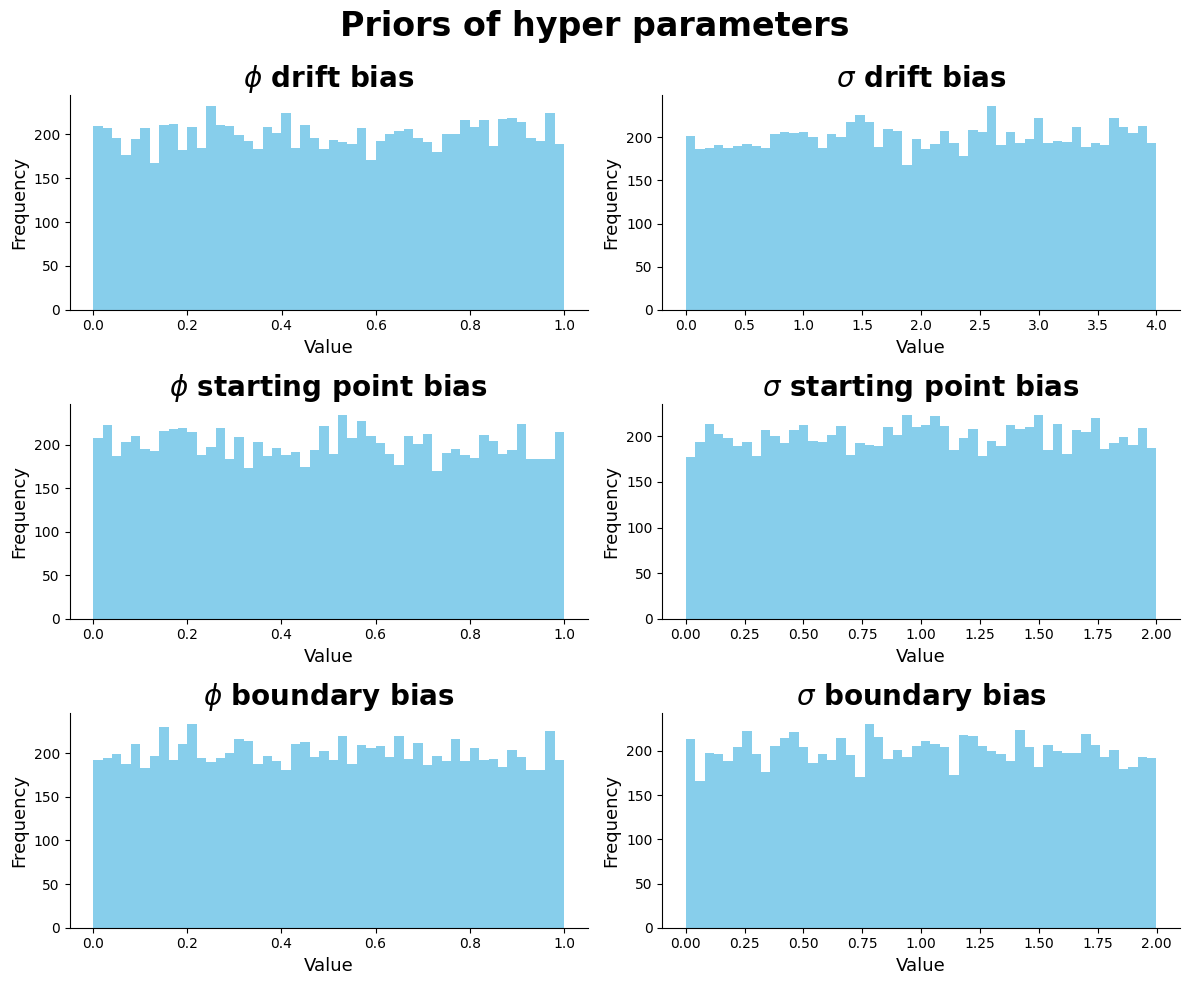

In [16]:
hyper_param_labels = ["$\phi$ drift bias","$\sigma$ drift bias","$\phi$ starting point bias","$\sigma$ starting point bias","$\phi$ boundary bias","$\sigma$ boundary bias"]
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, ax in enumerate(axes.flatten()):
    ax.hist(plot_prior['hyper_parameters'][:,i], bins=50, color='skyblue')
    ax.set_xlabel("Value", fontsize=13)
    ax.set_ylabel("Frequency", fontsize=13)
    ax.set_title(hyper_param_labels[i], fontsize=20, fontweight='bold')  
    sns.despine()   

fig.suptitle("Priors of hyper parameters", fontsize=24, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.99])
#plt.savefig('prior_hyper.png')
plt.show()

### Local parameters

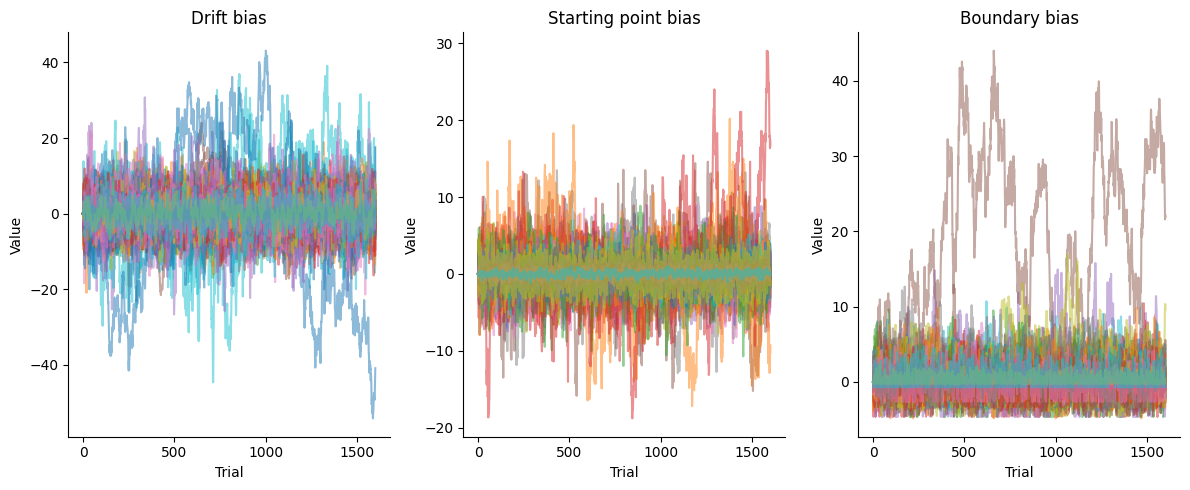

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
num_timeseries = 100

for i in range(num_timeseries): # drift bias
    axes[0].plot(plot_prior['local_parameters'][i, :, 0], alpha=.5)
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Value")
axes[0].set_title("Drift bias")
sns.despine(ax=axes[0])

for i in range(num_timeseries): # starting point bias
    axes[1].plot(plot_prior['local_parameters'][i, :, 1], alpha=.5)
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Value")
axes[1].set_title("Starting point bias")
sns.despine(ax=axes[1])

for i in range(num_timeseries): # boundary bias
    axes[2].plot(plot_prior['local_parameters'][i, :, 2], alpha=.5)
axes[2].set_xlabel("Trial")
axes[2].set_ylabel("Value")
axes[2].set_title("Boundary bias")
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

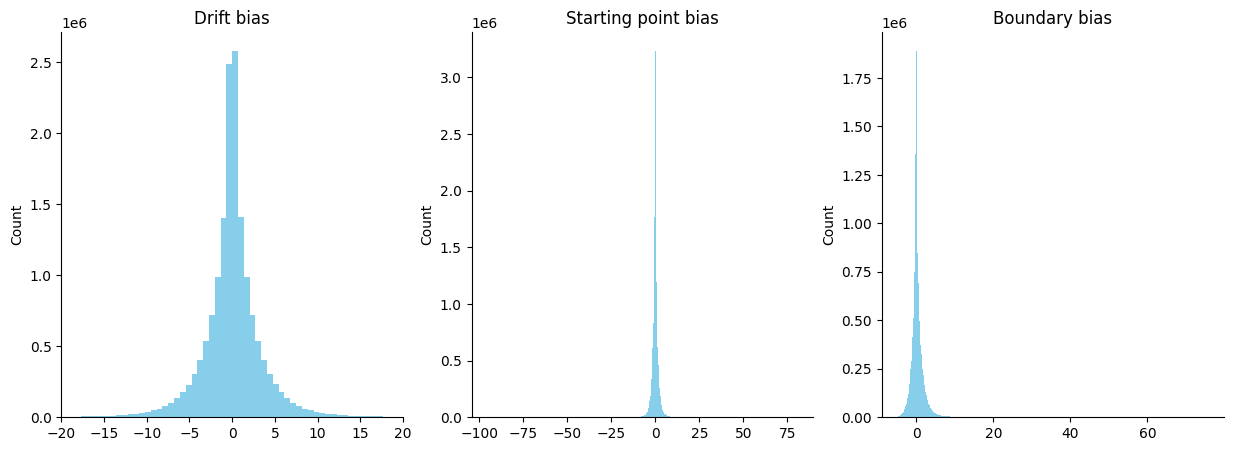

In [18]:
# Histogram over all time series
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(plot_prior['local_parameters'][:, :, 0].flatten(), color='skyblue', bins=500)
axes[0].set_title("Drift bias")
axes[0].set_ylabel("Count")
axes[0].set_xlim(-20,20)
sns.despine(ax=axes[0])

axes[1].hist(plot_prior['local_parameters'][:, :, 1].flatten(), color='skyblue', bins=500)
axes[1].set_title("Starting point bias")
axes[1].set_ylabel("Count")
sns.despine(ax=axes[1])

axes[2].hist(plot_prior['local_parameters'][:, :, 2].flatten(), color='skyblue', bins=500)
axes[2].set_title("Boundary bias")
axes[2].set_ylabel("Count")
sns.despine(ax=axes[2])

### RT distributions

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


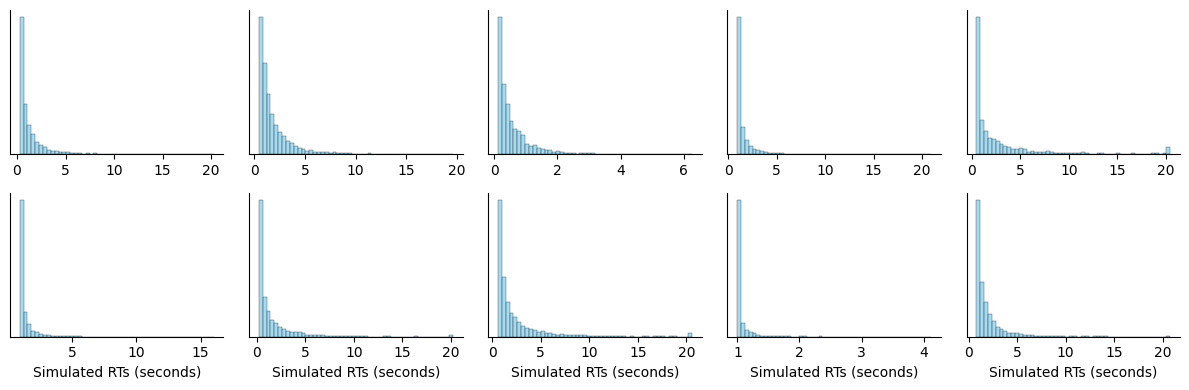

In [19]:
example_sim = generator(batch_size=10)

f, axarr = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axarr.flat):
    sns.histplot(example_sim["sim_data"][i, :, 0].flatten(), bins= 50, color="skyblue", alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_ylabel("")
    ax.set_yticks([])
    if i > 4:
        ax.set_xlabel("Simulated RTs (seconds)")
f.tight_layout()
plt.show()

## Setting up amortizer

In [20]:
""" 
summary_net: 
    learns the most informative summary stats from data 
inference_net: 
    from summary statistics to posterior distributions - joint posterior distribution
amortizer: 
    connects the two networks
"""

# Two-level summary network -> reduce 3D into 3D and 2D for local and global amortizer, respectively
summary_network = bf.networks.HierarchicalNetwork(
    [
        tf.keras.Sequential(
            [
                tf.keras.layers.LSTM(
                    512, return_sequences=True
                ),
                tf.keras.layers.LSTM(
                    256, return_sequences=True
                ),
                tf.keras.layers.LSTM(
                    128, return_sequences=True
                ),
            ]
        ),
        tf.keras.Sequential(
            [
                tf.keras.layers.LSTM(
                    64
                )
            ]
        )
    ]
)

# fluctuations for z bias, v bias, a bias
local_net = bf.amortizers.AmortizedPosterior(
    bf.networks.InvertibleNetwork(
        num_params=3, num_coupling_layers=8, coupling_design= 'interleaved'
    ))

# for hyper and shared parameters (first dimensions corresponds to hyperparameters, then shared)
# 6 hyper, 4 shared
global_net = bf.amortizers.AmortizedPosterior(
    bf.networks.InvertibleNetwork(
        num_params=10, num_coupling_layers=12, coupling_design= 'interleaved'
    ))

amortizer = bf.amortizers.TwoLevelAmortizedPosterior(
    local_net,
    global_net,
    summary_network
    )

2026-06-16 23:41:42.612285: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31128 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:b3:00.0, compute capability: 7.0


## Checkpoint path

In [21]:
checkpoint_path = f"/vsc-hard-mounts/leuven-data/343/vsc34314/DDM and clustered errors/6. Replication/3. Autocorrelated DDM/autocorrelated_ddm_training"
if not os.path.exists(checkpoint_path):
    os.makedirs(checkpoint_path)

## Create configurator

In [22]:

"""
takes the raw outputs of the generative models and turns them into something with which neural networks can work
"""


def configurator(raw_dict, transform=True):
        """Configures the output of self.generator for a BayesFlow pipeline.

        1. Converts float64 to float32 (for TensorFlow)
        2. Scale the model parameters if tranform=True

        Parameters:
        -----------
        raw_dict  : dict
            A simulation dictionary as returned by ``bayesflow.simulation.TwoLevelGenerativeModel``
        transform : boolean, optional, default: True
            An indicator to standardize the parameter and log-transform reaction times. 

        Returns:
        --------
        input_dict : dict
            The simulation dictionary configured for ``bayesflow.amortizers.TwoLevelAmortizer``
        """

        # Convert to float32
        shared_parameters = raw_dict.get("shared_prior_draws").astype(np.float32)
        hyper_parameters = raw_dict.get("hyper_prior_draws").astype(np.float32)
        local_parameters = raw_dict.get("local_prior_draws").astype(np.float32)


        # Convert list of condition indicators to a 2D array and add a
        # trailing dimension of 1, so shape becomes (batch_size, num_obs, 1)
        # We need this in order to easily concatenate the context (condition matrix) with the data
        context = np.array(raw_dict["prior_batchable_context"])[..., None]
        data = raw_dict.get("sim_data").astype(np.float32) # [batch_size, num_trials, 2], last dimension is (rt, resp)

        # Concatenate data (rt, resp) and context (condition matrix)
        summary_conditions = np.c_[data, context].astype(np.float32)

        # Make inference network aware of varying numbers of trials
        # We create a vector of shape (batch_size, 1) by repeating the sqrt(num_trials)
        # num_trials calculated as the length of the condition matrix
        vec_num_trials = context.shape[1] * np.ones((data.shape[0], 1))
        direct_conditions = np.sqrt(vec_num_trials).astype(np.float32)

        if transform:
            mean_shared, std_shared = return_mean_std_shared_parameters()
            mean_hyper, std_hyper = return_mean_std_hyper_parameters()
            
            # Log transform reaction times
            summary_conditions[:,:,0] = np.log(summary_conditions[:,:,0])
            
            out_dict = dict(
                shared_parameters=(shared_parameters-mean_shared.astype(np.float32))/std_shared.astype(np.float32),
                hyper_parameters=(hyper_parameters-mean_hyper.astype(np.float32))/std_hyper.astype(np.float32),
                local_parameters=local_parameters/5,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions # see https://bayesflow.org/_examples/LCA_Model_Posterior_Estimation.html#defining-the-configurator
            )
            
        else:
            out_dict = dict(
                shared_parameters=shared_parameters,
                hyper_parameters=hyper_parameters,
                local_parameters=local_parameters,
                summary_conditions=summary_conditions,
                direct_conditions=direct_conditions
            )

        return out_dict


In [23]:
raw_sample = generator(batch_size=3)
configured_output = configurator(raw_sample)

/data/leuven/343/vsc34314/miniconda3/envs/bf/lib/python3.10/site-packages/numba_cuda/numba/cuda/cudadrv/devicearray.py:938: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))


## Trainer setup

In [24]:
"""
Connect the networks (summary and inference) with the generative model 
"""

trainer = bf.trainers.Trainer(amortizer=amortizer,
                              generative_model=generator,
                              configurator=configurator,
                              checkpoint_path=checkpoint_path)

INFO:root:Initialized empty loss history.


INFO:root:Initialized networks from scratch.


INFO:root:Performing a consistency check with provided components...


2026-06-16 23:41:46.464922: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904


INFO:root:Done.


## Training

In [25]:

"""
Experience-replay training: 
    This training regime is also good for fast generative models 
    which can efficiently simulated data on-the-fly. It will use a memory replay buffer, 
    as utilized in reinforcement learning, so the network will eventually “experience” some 
    simulations multiple times. This allows it to reinforce its learning from these repeated experiences. 
    Experience replay can help improve learning efficiency and stability, especially in scenarios 
    where generating entirely new simulations on-the-fly for every training step may not be optimal.

epochs:
    This parameter defines the total number of complete passes through the training dataset. 
    Each epoch consists of several iterations, where the model is exposed to different subsets of the data.

iterations_per_epoch: 
    This specifies the number of training iterations that occur in each epoch. 
    During each iteration, the model is updated based on a batch of new data.

batch_size: 
    This determines the number of simulations in each batch. 
    It’s the size of the data subset that the model will see and learn from in each iteration.

validation_sims:
    A number of simulations where the network sees a completely new batch of data in each iteration
    This step is about assessing the model’s performance on a separate set of data that it hasn’t been trained on.
"""

losses = trainer.train_online(epochs=500,
                              iterations_per_epoch=1000,
                              batch_size=batch_size)

Training epoch 1:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-06-16 23:43:06.253126: I external/local_xla/xla/service/service.cc:168] XLA service 0x14f59d6df610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-16 23:43:06.253158: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Tesla V100-SXM2-32GB, Compute Capability 7.0
2026-06-16 23:43:06.340081: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1781646186.499323   70995 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Training epoch 2:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Training epoch 496:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 497:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 498:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 499:   0%|          | 0/1000 [00:00<?, ?it/s]

Training epoch 500:   0%|          | 0/1000 [00:00<?, ?it/s]

## Inspecting loss

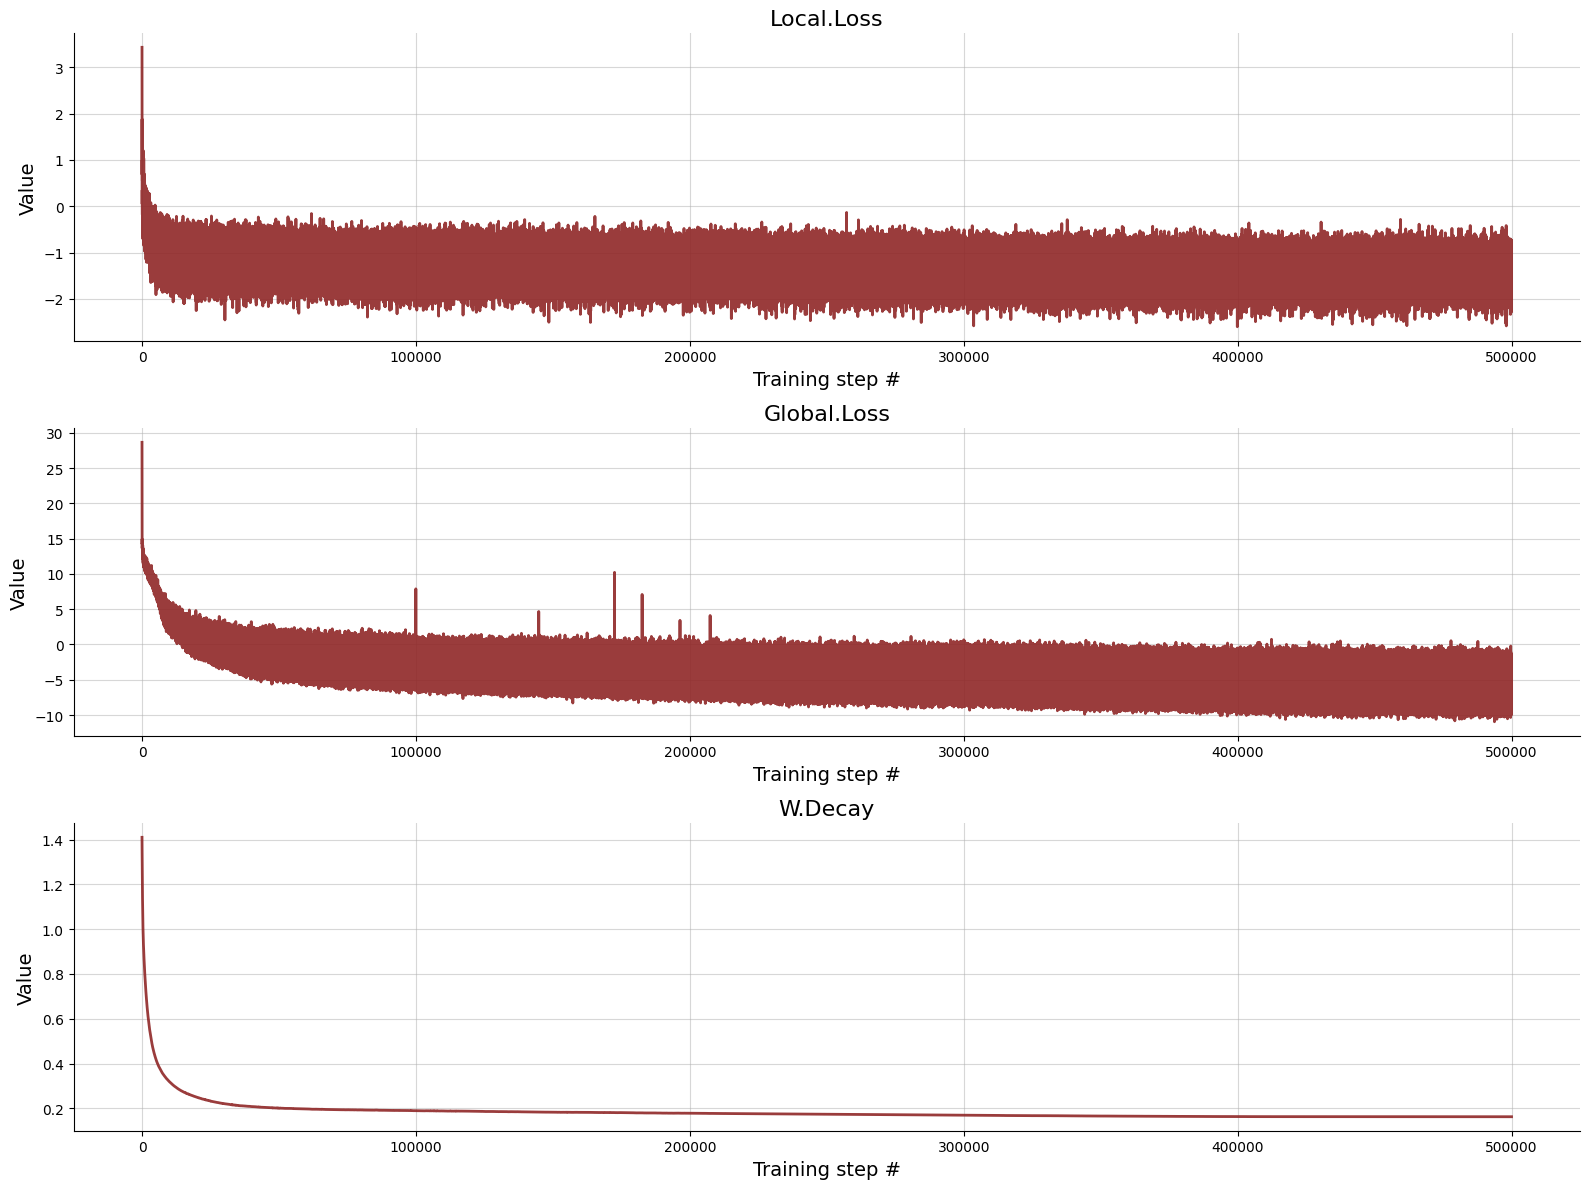

In [26]:
"""
A decreasing loss over time indicates that the model is learning effectively
"""

loss = bf.diagnostics.plot_losses(losses)
loss.savefig('Figures/autocorrelated_ddm_losses.png') 